# IEEE-CIS Fraud Detection - XGBoost


## 0. Setup

In [8]:
!pip install numpy pandas matplotlib seaborn scikit-learn mlflow
import os, gc, time, pickle, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.feature_selection import (mutual_info_classif, VarianceThreshold,
                                       SelectKBest, RFE)
from sklearn.inspection import permutation_importance

import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)


In [9]:
!pip install dagshub
import dagshub
REPO_OWNER = "rkvit23"
REPO_NAME  = "ML-HW2"
dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/rkvit23/ML-HW2.mlflow")


Initialized MLflow to track repo "rkvit23/ML-HW2"

Repository rkvit23/ML-HW2 initialized!

In [10]:
MODEL_TAG = 'XGBoost'
MLFLOW_EXPERIMENT = 'XGBoost_Training'
print('MLflow experiment:', MLFLOW_EXPERIMENT)

MLflow experiment: XGBoost_Training


In [11]:
DATA_DIR = "/kaggle/input/competitions/ieee-fraud-detection/" 
SAMPLE_FRAC = 1.0        

def reduce_mem(df):
    """Downcast numeric dtypes - typical 50-70% memory saving."""
    start = df.memory_usage(deep=True).sum() / 1024**2
    for c in df.columns:
        col = df[c]
        if pd.api.types.is_integer_dtype(col):
            df[c] = pd.to_numeric(col, downcast="integer")
        elif pd.api.types.is_float_dtype(col):
            df[c] = pd.to_numeric(col, downcast="float")
    end = df.memory_usage(deep=True).sum() / 1024**2
    print(f"  memory: {start:.1f} MB -> {end:.1f} MB  ({100*(start-end)/start:.1f}% saved)")
    return df

print("Loading transaction tables...")
train_tx = pd.read_csv(os.path.join(DATA_DIR, "train_transaction.csv"))
test_tx  = pd.read_csv(os.path.join(DATA_DIR, "test_transaction.csv"))
print("Loading identity tables...")
train_id = pd.read_csv(os.path.join(DATA_DIR, "train_identity.csv"))
test_id  = pd.read_csv(os.path.join(DATA_DIR, "test_identity.csv"))

# Test identity columns are named with '-' instead of '_' in the official files
test_id.columns = [c.replace('-', '_') for c in test_id.columns]

train = train_tx.merge(train_id, on="TransactionID", how="left")
test  = test_tx.merge(test_id,  on="TransactionID", how="left")
del train_tx, test_tx, train_id, test_id; gc.collect()

if SAMPLE_FRAC < 1.0:
    train = train.sample(frac=SAMPLE_FRAC, random_state=SEED).reset_index(drop=True)

train = reduce_mem(train)
test  = reduce_mem(test)

print(f"\nTrain shape: {train.shape}   |  fraud rate: {train['isFraud'].mean():.4f}")
print(f"Test  shape: {test.shape}")


Loading transaction tables...
Loading identity tables...
  memory: 2514.0 MB -> 1603.3 MB  (36.2% saved)
  memory: 2164.1 MB -> 1386.1 MB  (35.9% saved)

Train shape: (590540, 434)   |  fraud rate: 0.0350
Test  shape: (506691, 433)


Class distribution:
isFraud
0    0.96501
1    0.03499
Name: pct, dtype: float64


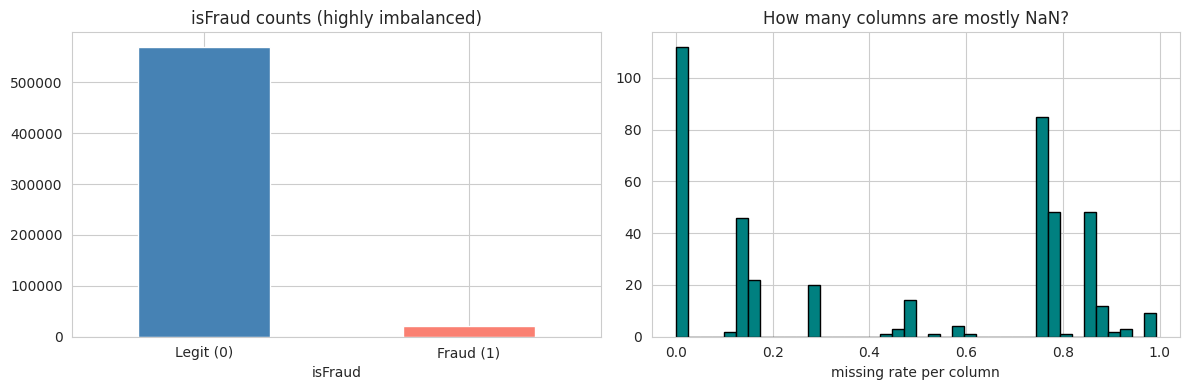


Columns with >50% missing values: 214  / 434
Columns with >90% missing values: 12


In [12]:
# Quick sanity check on class balance and missing rate.
print("Class distribution:")
print(train['isFraud'].value_counts(normalize=True).rename('pct'))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
train['isFraud'].value_counts().plot(kind='bar', ax=ax[0], color=['steelblue','salmon'])
ax[0].set_title('isFraud counts (highly imbalanced)')
ax[0].set_xticklabels(['Legit (0)','Fraud (1)'], rotation=0)

miss = train.isnull().mean().sort_values(ascending=False)
ax[1].hist(miss.values, bins=40, color='teal', edgecolor='black')
ax[1].set_xlabel('missing rate per column')
ax[1].set_title('How many columns are mostly NaN?')
plt.tight_layout(); plt.show()

print(f"\nColumns with >50% missing values: {(miss > 0.5).sum()}  / {train.shape[1]}")
print(f"Columns with >90% missing values: {(miss > 0.9).sum()}")


## 1. Cleaning

In [13]:
TARGET = "isFraud"
ID_COL = "TransactionID"

def analyse_missing(df, name):
    miss = df.isnull().mean().sort_values(ascending=False)
    almost_empty = miss[miss > 0.95].index.tolist()
    constant     = [c for c in df.columns
                    if df[c].nunique(dropna=False) <= 1]
    print(f"[{name}]  >95% NaN: {len(almost_empty)}   constant: {len(constant)}")
    return sorted(set(almost_empty + constant))

drop_train = analyse_missing(train, "train")
drop_test  = analyse_missing(test,  "test")
DROP_COLS = sorted(set(drop_train) | set(drop_test))
DROP_COLS = [c for c in DROP_COLS if c not in (TARGET, ID_COL)]

print(f"\nWill drop {len(DROP_COLS)} useless columns:")
print(DROP_COLS[:25], "...")

train.drop(columns=DROP_COLS, inplace=True, errors='ignore')
test.drop(columns=DROP_COLS,  inplace=True, errors='ignore')

print(f"\nAfter cleaning - train: {train.shape}, test: {test.shape}")
gc.collect()


[train]  >95% NaN: 9   constant: 0
[test]  >95% NaN: 9   constant: 1

Will drop 10 useless columns:
['V107', 'id_07', 'id_08', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27'] ...

After cleaning - train: (590540, 424), test: (506691, 423)


20

## 2. Feature Engineering



In [14]:
EMAIL_HIGH_RISK = {'protonmail.com','mail.com','outlook.es','aim.com',
                   'anonymous.com'}

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """All the engineered features (time, email, amount, aggregations)."""
    def __init__(self):
        self.card1_amt_mean_ = None
        self.card1_amt_std_  = None
        self.freq_maps_      = {}

    def fit(self, X, y=None):
        # Aggregations learned only on TRAIN
        if 'card1' in X.columns and 'TransactionAmt' in X.columns:
            g = X.groupby('card1')['TransactionAmt']
            self.card1_amt_mean_ = g.mean()
            self.card1_amt_std_  = g.std().fillna(0)
        for col in ['card1','card2','card3','card5','addr1','P_emaildomain',
                    'R_emaildomain']:
            if col in X.columns:
                self.freq_maps_[col] = X[col].value_counts(dropna=False)
        return self

    def transform(self, X):
        X = X.copy()
        # ---- time decomposition ----
        if 'TransactionDT' in X.columns:
            X['TX_hour']   = (X['TransactionDT'] // 3600) % 24
            X['TX_day']    = (X['TransactionDT'] // 86400)
            X['TX_dow']    = (X['TX_day'] % 7).astype('int8')
        # ---- amount features ----
        if 'TransactionAmt' in X.columns:
            X['TX_amt_log']     = np.log1p(X['TransactionAmt'])
            X['TX_amt_decimal'] = ((X['TransactionAmt'] -
                                    np.floor(X['TransactionAmt'])) * 1000).astype('int32')
        # ---- email features ----
        for col in ['P_emaildomain','R_emaildomain']:
            if col in X.columns:
                base = X[col].fillna('NA').astype(str)
                X[col + '_base'] = base.str.split('.').str[0]
                X[col + '_suf']  = base.str.split('.').str[-1]
                X[col + '_risk'] = base.isin(EMAIL_HIGH_RISK).astype('int8')
        # ---- card1 aggregations ----
        if self.card1_amt_mean_ is not None and 'card1' in X.columns:
            X['card1_amt_mean'] = X['card1'].map(self.card1_amt_mean_)
            X['card1_amt_std']  = X['card1'].map(self.card1_amt_std_)
            X['card1_amt_diff'] = X['TransactionAmt'] - X['card1_amt_mean']
        # ---- frequency encoding ----
        for col, fmap in self.freq_maps_.items():
            X[col + '_freq'] = X[col].map(fmap).fillna(0).astype('float32')
        return X


class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """Label-encode every object column the same way for train+test.
    Unknown test categories -> -1 (sentinel)."""
    def __init__(self):
        self.maps_ = {}

    def fit(self, X, y=None):
        for c in X.columns:
            if X[c].dtype == 'object' or X[c].dtype.name == 'category':
                vals = X[c].astype(str).fillna('NA').unique()
                self.maps_[c] = {v: i for i, v in enumerate(vals)}
        return self

    def transform(self, X):
        X = X.copy()
        for c, m in self.maps_.items():
            if c in X.columns:
                X[c] = X[c].astype(str).fillna('NA').map(m).fillna(-1).astype('int32')
        return X


class Imputer(BaseEstimator, TransformerMixin):
    """Median imputation for numeric, -1 for categorical/encoded.
    Also clips +-inf to NaN first so downstream models never see a non-finite value."""
    def __init__(self):
        self.medians_ = None

    def fit(self, X, y=None):
        Xc = X.replace([np.inf, -np.inf], np.nan)
        self.medians_ = Xc.median(numeric_only=True)
        return self

    def transform(self, X):
        X = X.copy()
        # Inf -> NaN first (e.g. card1_amt_diff after float32 downcast)
        X = X.replace([np.inf, -np.inf], np.nan)
        for c in X.columns:
            if X[c].isnull().any():
                X[c] = X[c].fillna(self.medians_.get(c, -1))
        # any remaining NaN (e.g. all-NaN col, object col) -> -1
        return X.fillna(-1)


In [15]:
# Build raw matrices we will pass through the FE pipeline
y          = train[TARGET].values
X_train_raw = train.drop(columns=[TARGET, ID_COL])
X_test_raw  = test.drop(columns=[ID_COL])
print(f"Raw shapes: train {X_train_raw.shape}, test {X_test_raw.shape}")

fe_pipeline = Pipeline([
    ('feat',    FeatureEngineer()),
    ('catenc',  CategoricalEncoder()),
    ('impute',  Imputer()),
])

fe_pipeline.fit(X_train_raw, y)
X_train_fe = fe_pipeline.transform(X_train_raw)
X_test_fe  = fe_pipeline.transform(X_test_raw)
print(f"After FE  : train {X_train_fe.shape}, test {X_test_fe.shape}")

# Hard sanity: nothing non-finite reaches feature selection / models.
# (mutual_info_classif and VarianceThreshold both call check_array with
#  force_all_finite=True and will raise ValueError otherwise.)
def assert_finite(df, name):
    nans = int(df.isnull().sum().sum())
    infs = int(np.isinf(df.select_dtypes(include=[np.number]).values).sum())
    print(f"  [{name}] NaNs={nans}, Infs={infs}")
    if nans or infs:
        # belt-and-braces: replace and continue
        df.replace([np.inf, -np.inf], 0, inplace=True)
        df.fillna(0, inplace=True)
        print(f"  [{name}] -> cleaned to all-finite")
    return df

X_train_fe = assert_finite(X_train_fe, 'train_fe')
X_test_fe  = assert_finite(X_test_fe,  'test_fe')


Raw shapes: train (590540, 422), test (506691, 422)
After FE  : train (590540, 443), test (506691, 443)
  [train_fe] NaNs=0, Infs=0
  [test_fe] NaNs=0, Infs=0


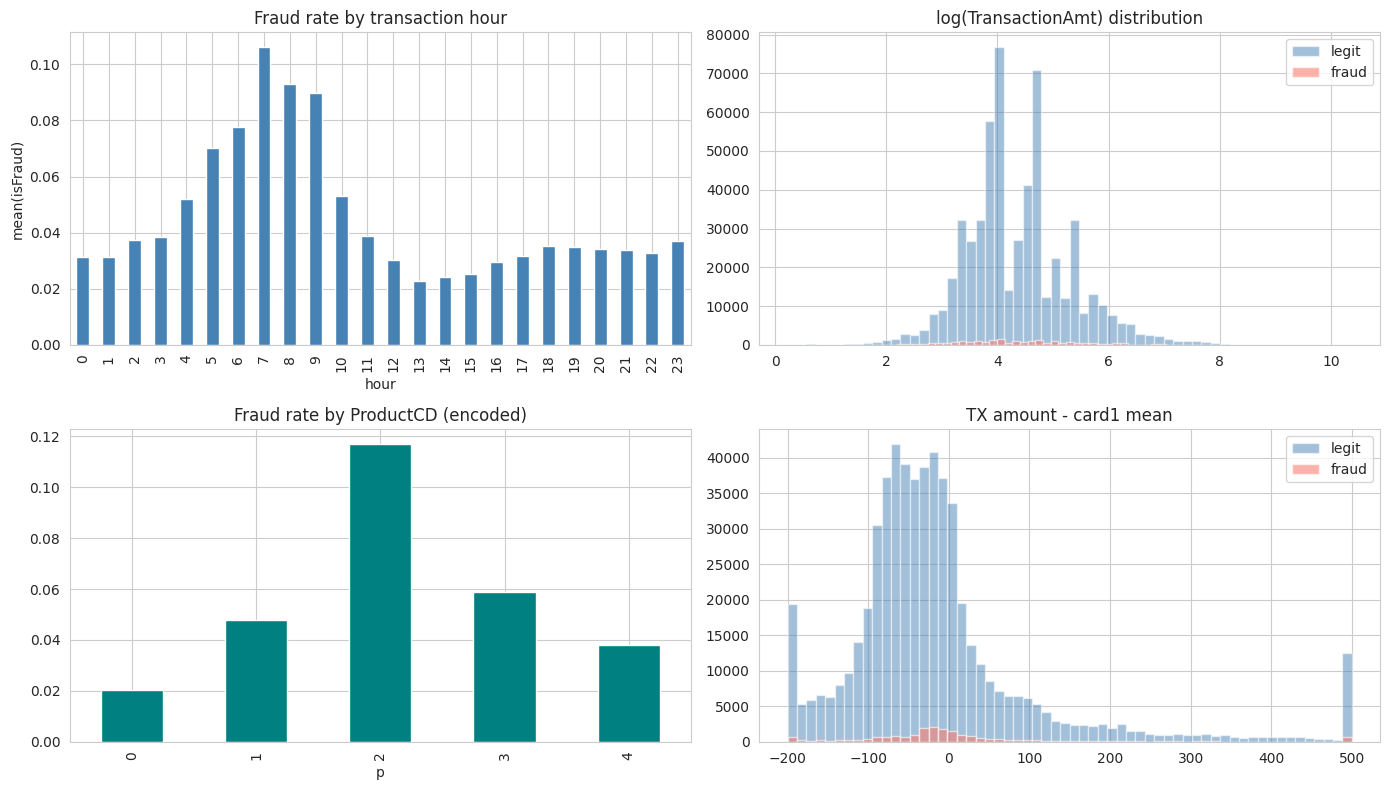

In [16]:
# Visualise a few engineered features vs target
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

# fraud rate by hour
hr = pd.DataFrame({'hour': X_train_fe['TX_hour'], 'fraud': y})
hr.groupby('hour')['fraud'].mean().plot(kind='bar', ax=ax[0,0], color='steelblue')
ax[0,0].set_title('Fraud rate by transaction hour')
ax[0,0].set_ylabel('mean(isFraud)')

# log amount distribution
ax[0,1].hist(X_train_fe.loc[y==0,'TX_amt_log'], bins=60, alpha=.5, label='legit', color='steelblue')
ax[0,1].hist(X_train_fe.loc[y==1,'TX_amt_log'], bins=60, alpha=.6, label='fraud', color='salmon')
ax[0,1].legend(); ax[0,1].set_title('log(TransactionAmt) distribution')

# fraud rate by ProductCD if encoded
if 'ProductCD' in X_train_fe.columns:
    pcd = pd.DataFrame({'p': X_train_fe['ProductCD'], 'fraud': y})
    pcd.groupby('p')['fraud'].mean().plot(kind='bar', ax=ax[1,0], color='teal')
    ax[1,0].set_title('Fraud rate by ProductCD (encoded)')

# card1_amt_diff for fraud vs legit
if 'card1_amt_diff' in X_train_fe.columns:
    ax[1,1].hist(X_train_fe.loc[y==0,'card1_amt_diff'].clip(-200,500), bins=60,
                 alpha=.5, label='legit', color='steelblue')
    ax[1,1].hist(X_train_fe.loc[y==1,'card1_amt_diff'].clip(-200,500), bins=60,
                 alpha=.6, label='fraud', color='salmon')
    ax[1,1].legend(); ax[1,1].set_title('TX amount - card1 mean')

plt.tight_layout(); plt.show()




## 3. Feature Selection



VarianceThreshold (constants out): kept 443


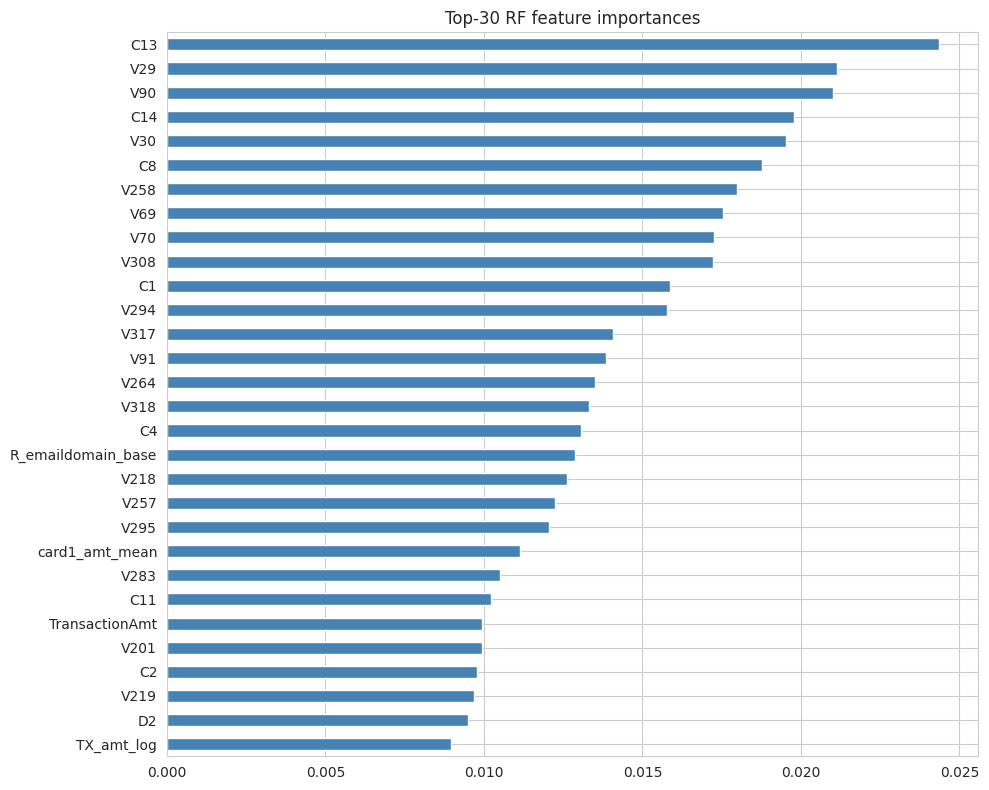

Permutation > 0.0001 -> 185 features
  all_after_VT         -> 443 features
  RF_top80             -> 80 features
  PermImp>0.0001       -> 185 features


In [17]:
from sklearn.ensemble import RandomForestClassifier as _QuickRF

# 3.1 Variance threshold
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_fe)
keep_vt = X_train_fe.columns[vt.get_support()].tolist()
print(f"VarianceThreshold (constants out): kept {len(keep_vt)}")

# 3.2 RF embedded importance (fit on a subsample for speed)
sample_idx = np.random.RandomState(SEED).choice(len(X_train_fe),
                                                size=min(80000, len(X_train_fe)),
                                                replace=False)
imp_rf = _QuickRF(n_estimators=120, max_depth=10, n_jobs=-1,
                  class_weight='balanced', random_state=SEED)
imp_rf.fit(X_train_fe[keep_vt].iloc[sample_idx], y[sample_idx])
imp_series = pd.Series(imp_rf.feature_importances_, index=keep_vt
                       ).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
imp_series.head(30).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis(); ax.set_title('Top-30 RF feature importances')
plt.tight_layout(); plt.show()

TOPK_RF = 80
keep_rf = imp_series.head(TOPK_RF).index.tolist()

# 3.3 Permutation importance on a smaller sample
perm_idx = np.random.RandomState(SEED).choice(len(X_train_fe),
                                              size=min(20000, len(X_train_fe)),
                                              replace=False)
perm_res = permutation_importance(imp_rf, X_train_fe[keep_vt].iloc[perm_idx],
                                  y[perm_idx], n_repeats=3, n_jobs=-1,
                                  random_state=SEED, scoring='roc_auc')
perm_series = pd.Series(perm_res.importances_mean, index=keep_vt
                        ).sort_values(ascending=False)
keep_perm = perm_series[perm_series > 0.0001].index.tolist()
print(f"Permutation > 0.0001 -> {len(keep_perm)} features")

FEATURE_SETS = {
    'all_after_VT'        : keep_vt,
    f'RF_top{TOPK_RF}'    : keep_rf,
    'PermImp>0.0001'      : keep_perm,
}
for name, cols in FEATURE_SETS.items():
    print(f"  {name:20s} -> {len(cols)} features")


  all_after_VT              |  443 feats | AUC = 0.87246 (+/- 0.00374)
  RF_top80                  |   80 feats | AUC = 0.87591 (+/- 0.00504)
  PermImp>0.0001            |  185 feats | AUC = 0.87626 (+/- 0.00391)

Best FS = PermImp>0.0001  (185 features)


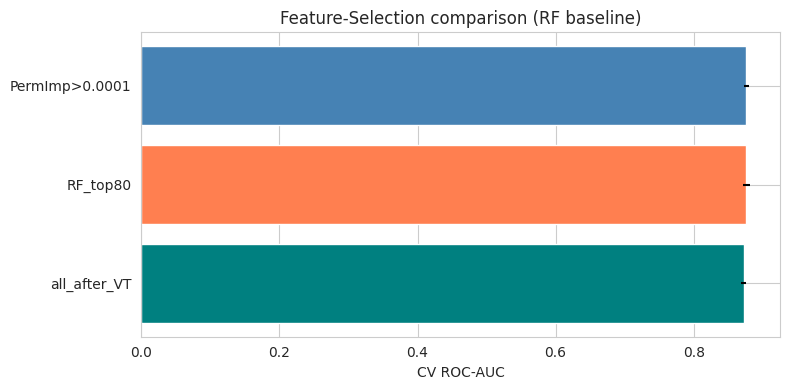

In [18]:
from sklearn.ensemble import RandomForestClassifier as _QuickRF
quick = _QuickRF(n_estimators=80, max_depth=8, n_jobs=-1,
                 class_weight='balanced', random_state=SEED)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
sample_idx = np.random.RandomState(SEED).choice(len(X_train_fe),
                                                size=min(60000, len(X_train_fe)),
                                                replace=False)

fs_results = []
for name, cols in FEATURE_SETS.items():
    Xs = X_train_fe[cols].iloc[sample_idx].values
    aucs = cross_val_score(quick, Xs, y[sample_idx], cv=cv,
                           scoring='roc_auc', n_jobs=-1)
    fs_results.append({'method': name, 'n_feat': len(cols),
                       'mean_auc': aucs.mean(), 'std_auc': aucs.std()})
    print(f"  {name:25s} | {len(cols):4d} feats | AUC = {aucs.mean():.5f} (+/- {aucs.std():.5f})")

fs_df = pd.DataFrame(fs_results).sort_values('mean_auc', ascending=False)
best_fs_name = fs_df.iloc[0]['method']
SELECTED_FEATURES = FEATURE_SETS[best_fs_name]
print(f"\nBest FS = {best_fs_name}  ({len(SELECTED_FEATURES)} features)")

fig, ax = plt.subplots(figsize=(8,4))
ax.barh(fs_df['method'], fs_df['mean_auc'], xerr=fs_df['std_auc'],
        color=['steelblue','coral','teal'])
ax.set_xlabel('CV ROC-AUC'); ax.invert_yaxis()
ax.set_title('Feature-Selection comparison (RF baseline)')
plt.tight_layout(); plt.show()



## 4. Training - XGBoost




In [19]:
def fit_eval(model, X_tr, y_tr, X_val, y_val, cv=None):
    """Train + return metrics dict (no MLflow side-effects)."""
    model.fit(X_tr, y_tr)
    if hasattr(model, "predict_proba"):
        p_tr  = model.predict_proba(X_tr)[:, 1]
        p_val = model.predict_proba(X_val)[:, 1]
    else:
        p_tr  = model.decision_function(X_tr)
        p_val = model.decision_function(X_val)
    pr_tr  = (p_tr  > 0.5).astype(int)
    pr_val = (p_val > 0.5).astype(int)
    metrics = {
        'train_auc'   : roc_auc_score(y_tr,  p_tr),
        'val_auc'     : roc_auc_score(y_val, p_val),
        'train_ap'    : average_precision_score(y_tr,  p_tr),
        'val_ap'      : average_precision_score(y_val, p_val),
        'val_f1'      : f1_score(y_val, pr_val, zero_division=0),
        'val_prec'    : precision_score(y_val, pr_val, zero_division=0),
        'val_recall'  : recall_score(y_val, pr_val, zero_division=0),
        'overfit_gap' : roc_auc_score(y_tr, p_tr) - roc_auc_score(y_val, p_val),
    }
    if cv is not None:
        cv_aucs = cross_val_score(model, X_tr, y_tr, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)
        metrics['cv_auc_mean'] = cv_aucs.mean()
        metrics['cv_auc_std']  = cv_aucs.std()
    return metrics

def print_m(tag, m):
    print(f"  [{tag}]")
    for k, v in m.items():
        print(f"    {k:14s} = {v:.5f}")

results_log = []


In [20]:
import xgboost as xgb

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_sel = X_train_fe[SELECTED_FEATURES].astype(np.float32).values
X_tr, X_val, y_tr, y_val = train_test_split(X_sel, y, test_size=0.2,
                                            stratify=y, random_state=SEED)

# Compute scale_pos_weight from training data
spw = (y_tr == 0).sum() / max(1, (y_tr == 1).sum())
print(f"scale_pos_weight = {spw:.2f}")


scale_pos_weight = 27.58


In [21]:
m = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, eval_metric='auc', tree_method='hist', random_state=SEED, n_jobs=-1)
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("default-ish lr=0.1 n=300 d=6", mt)
results_log.append({'name': "XGB_default-ish lr=0.1 n=300 d=6", 'model': m, **mt})


  [default-ish lr=0.1 n=300 d=6]
    train_auc      = 0.96809
    val_auc        = 0.95038
    train_ap       = 0.81349
    val_ap         = 0.74692
    val_f1         = 0.65261
    val_prec       = 0.92067
    val_recall     = 0.50544
    overfit_gap    = 0.01771


In [22]:
m = xgb.XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=8, scale_pos_weight=spw, eval_metric='auc', tree_method='hist', random_state=SEED, n_jobs=-1)
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("lr=0.05 n=600 d=8 spw", mt)
results_log.append({'name': "XGB_lr=0.05 n=600 d=8 spw", 'model': m, **mt})


  [lr=0.05 n=600 d=8 spw]
    train_auc      = 0.99464
    val_auc        = 0.96712
    train_ap       = 0.92005
    val_ap         = 0.78859
    val_f1         = 0.58892
    val_prec       = 0.45465
    val_recall     = 0.83571
    overfit_gap    = 0.02752


In [23]:
m = xgb.XGBClassifier(n_estimators=800, learning_rate=0.05, max_depth=10, subsample=0.8, colsample_bytree=0.7, scale_pos_weight=spw, eval_metric='auc', tree_method='hist', random_state=SEED, n_jobs=-1)
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("lr=0.05 n=800 d=10 sub=0.8 cs=0.7", mt)
results_log.append({'name': "XGB_lr=0.05 n=800 d=10 sub=0.8 cs=0.7", 'model': m, **mt})


  [lr=0.05 n=800 d=10 sub=0.8 cs=0.7]
    train_auc      = 0.99999
    val_auc        = 0.97589
    train_ap       = 0.99984
    val_ap         = 0.86638
    val_f1         = 0.81186
    val_prec       = 0.84408
    val_recall     = 0.78200
    overfit_gap    = 0.02410


In [24]:
m = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, reg_lambda=10, eval_metric='auc', tree_method='hist', random_state=SEED, n_jobs=-1)
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("lr=0.1 n=300 d=6 reg_l2=10", mt)
results_log.append({'name': "XGB_lr=0.1 n=300 d=6 reg_l2=10", 'model': m, **mt})


  [lr=0.1 n=300 d=6 reg_l2=10]
    train_auc      = 0.96238
    val_auc        = 0.94619
    train_ap       = 0.78596
    val_ap         = 0.72639
    val_f1         = 0.63458
    val_prec       = 0.90692
    val_recall     = 0.48802
    overfit_gap    = 0.01619


In [25]:
m = xgb.XGBClassifier(n_estimators=1200, learning_rate=0.03, max_depth=8, min_child_weight=10, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.7, eval_metric='auc', tree_method='hist', random_state=SEED, n_jobs=-1)
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("lr=0.03 n=1200 d=8 strict reg", mt)
results_log.append({'name': "XGB_lr=0.03 n=1200 d=8 strict reg", 'model': m, **mt})


  [lr=0.03 n=1200 d=8 strict reg]
    train_auc      = 0.99788
    val_auc        = 0.97164
    train_ap       = 0.95385
    val_ap         = 0.81341
    val_f1         = 0.64847
    val_prec       = 0.52957
    val_recall     = 0.83620
    overfit_gap    = 0.02624


In [26]:
m = xgb.XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=4, scale_pos_weight=spw, reg_alpha=0.5, reg_lambda=2.0, eval_metric='auc', tree_method='hist', random_state=SEED, n_jobs=-1)
mt = fit_eval(m, X_tr, y_tr, X_val, y_val)
print_m("shallow lr=0.1 n=500 d=4 reg", mt)
results_log.append({'name': "XGB_shallow lr=0.1 n=500 d=4 reg", 'model': m, **mt})


  [shallow lr=0.1 n=500 d=4 reg]
    train_auc      = 0.96019
    val_auc        = 0.94385
    train_ap       = 0.70030
    val_ap         = 0.65665
    val_f1         = 0.38982
    val_prec       = 0.25451
    val_recall     = 0.83233
    overfit_gap    = 0.01634


                                 name  train_auc  val_auc   val_f1   val_ap  overfit_gap    diagnosis
XGB_lr=0.05 n=800 d=10 sub=0.8 cs=0.7   0.999994 0.975894 0.811856 0.866378     0.024101 mild-overfit
    XGB_lr=0.03 n=1200 d=8 strict reg   0.997884 0.971642 0.648466 0.813415     0.026243 mild-overfit
            XGB_lr=0.05 n=600 d=8 spw   0.994636 0.967118 0.588917 0.788591     0.027518 mild-overfit
     XGB_default-ish lr=0.1 n=300 d=6   0.968087 0.950381 0.652609 0.746924     0.017706      HEALTHY
       XGB_lr=0.1 n=300 d=6 reg_l2=10   0.962379 0.946191 0.634576 0.726394     0.016188      HEALTHY
     XGB_shallow lr=0.1 n=500 d=4 reg   0.960190 0.943851 0.389824 0.656649     0.016339      HEALTHY


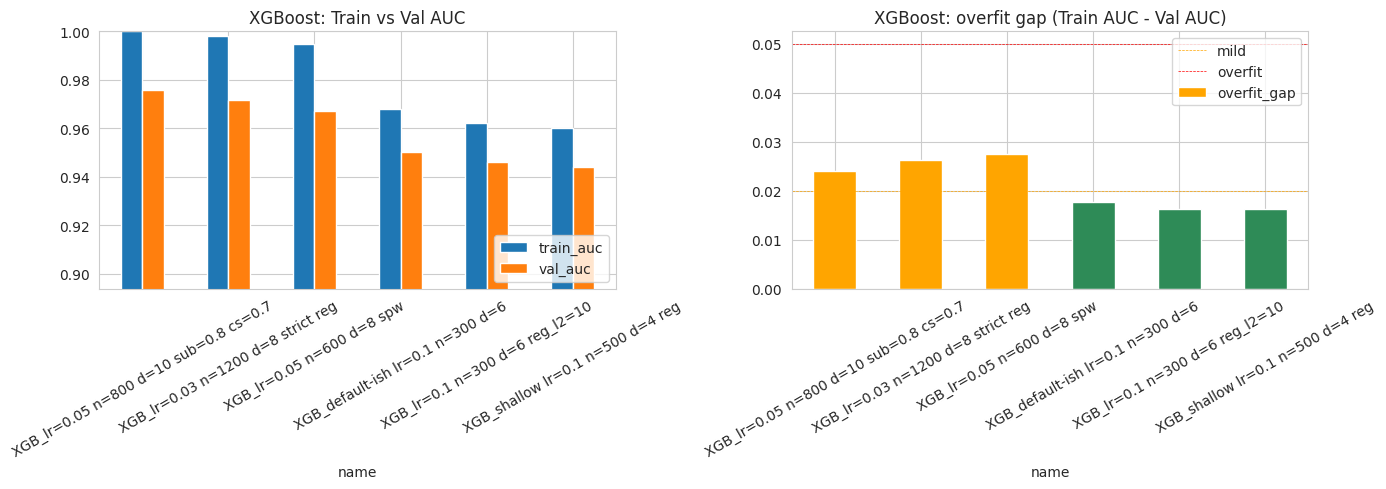

-> picked best_model = XGB_lr=0.05 n=800 d=10 sub=0.8 cs=0.7


In [27]:
df_results = pd.DataFrame([{k:v for k,v in r.items() if k!='model'} for r in results_log])
df_results = df_results.sort_values('val_auc', ascending=False).reset_index(drop=True)


def _diag(row):
    if row['train_auc'] < 0.75:
        return 'UNDERFIT'
    if row['overfit_gap'] > 0.05:
        return 'OVERFIT'
    if row['overfit_gap'] < 0:
        return 'lucky-val'
    if row['val_auc'] >= 0.85 and row['overfit_gap'] <= 0.02:
        return 'HEALTHY'
    return 'mild-overfit' if row['overfit_gap'] > 0.02 else 'ok'
df_results['diagnosis'] = df_results.apply(_diag, axis=1)

_default_cols = ['name','train_auc','val_auc','val_f1','val_ap','overfit_gap','diagnosis']
show_cols = [c for c in _default_cols if c in df_results.columns]
print(df_results[show_cols].to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df_results.set_index('name')[['train_auc','val_auc']].plot(kind='bar', ax=ax[0])
ax[0].set_title('XGBoost: Train vs Val AUC')
ax[0].set_ylim(max(0.5, df_results[['train_auc','val_auc']].min().min()-0.05), 1.0)
ax[0].tick_params(axis='x', rotation=30); ax[0].legend(loc='lower right')

colors = ['salmon' if g > 0.05 else ('orange' if g > 0.02 else 'seagreen')
          for g in df_results['overfit_gap']]
df_results.set_index('name')['overfit_gap'].plot(kind='bar', ax=ax[1], color=colors)
ax[1].axhline(0,    color='black', lw=0.5)
ax[1].axhline(0.02, color='orange', ls='--', lw=0.5, label='mild')
ax[1].axhline(0.05, color='red',    ls='--', lw=0.5, label='overfit')
ax[1].set_title('XGBoost: overfit gap (Train AUC - Val AUC)')
ax[1].tick_params(axis='x', rotation=30); ax[1].legend(loc='upper right')
plt.tight_layout(); plt.show()

n_over   = int((df_results['diagnosis']=='OVERFIT').sum())
n_under  = int((df_results['diagnosis']=='UNDERFIT').sum())
n_health = int((df_results['diagnosis']=='HEALTHY').sum())
best     = df_results.iloc[0]
worst    = df_results.iloc[-1]

best_model = [r['model'] for r in results_log if r['name']==best['name']][0]
print(f"-> picked best_model = {best['name']}")


## 5. Pipeline Construction & Save



In [28]:
import pickle
from sklearn.pipeline import Pipeline

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, cols): self.cols = cols
    def fit(self, X, y=None): return self
    def transform(self, X): return X[self.cols]

# Build a single pipeline that runs on RAW test data
final_pipeline = Pipeline([
    ('feat',   FeatureEngineer()),
    ('catenc', CategoricalEncoder()),
    ('impute', Imputer()),
    ('select', ColumnSelector(SELECTED_FEATURES)),
    ('model',  best_model),
])

# Refit FE part + best model on the FULL training data (raw)
final_pipeline.fit(X_train_raw, y)
print("Pipeline fitted on full raw training data.")

# Sanity: probabilistic predictions on raw test
test_pred_proba = final_pipeline.predict_proba(X_test_raw)[:, 1]
print(f"Test prediction probabilities sample: {test_pred_proba[:5]}")
print(f"Mean predicted P(fraud) on test set : {test_pred_proba.mean():.4f}")

# Save pipeline locally too (optional)
PIPE_PATH = f"pipeline_{MODEL_TAG}.pkl"
with open(PIPE_PATH, 'wb') as f:
    pickle.dump(final_pipeline, f)
print(f"Pipeline saved to {PIPE_PATH}")


Pipeline fitted on full raw training data.
Test prediction probabilities sample: [2.3085300e-05 1.4788612e-04 2.2904872e-04 5.3286459e-04 8.3923180e-05]
Mean predicted P(fraud) on test set : 0.0391
Pipeline saved to pipeline_XGBoost.pkl


## 6. MLflow Logging



In [29]:
# 6.3  Cleaning summary run
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Cleaning"):
    mlflow.log_param('stage', 'cleaning')
    mlflow.log_param('dropped_columns', len(DROP_COLS))
    mlflow.log_param('train_shape_after', str(train.shape))
    mlflow.log_param('test_shape_after',  str(test.shape))
print("Cleaning run logged.")


2026/05/04 15:59:27 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Training' does not exist. Creating a new experiment.


🏃 View run XGBoost_Cleaning at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7/runs/591cc3d9eb6d4f76899dc1087c318895
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7
Cleaning run logged.


In [30]:
# 6.2  Feature-Selection comparison run
mlflow.set_experiment(MLFLOW_EXPERIMENT)

import re
def _safe(s):
    # MLflow allows only [A-Za-z0-9_.\-: /] in metric / param keys.
    return re.sub(r'[^A-Za-z0-9_.\-: /]', '_', str(s))

with mlflow.start_run(run_name=f"{MODEL_TAG}_Feature_Selection"):
    mlflow.log_param('stage',     'feature_selection')
    mlflow.log_param('chosen',    best_fs_name if 'best_fs_name' in dir() else 'n/a')
    mlflow.log_param('n_selected', len(SELECTED_FEATURES))
    if 'fs_df' in dir():
        for _, row in fs_df.iterrows():
            mlflow.log_metric(f"AUC_{_safe(row['method'])}", float(row['mean_auc']))
print("Feature Selection run logged.")

🏃 View run XGBoost_Feature_Selection at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7/runs/92f052a0fc204a8bbcf019144f50515f
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7
Feature Selection run logged.


In [31]:
# 6.3.5  Feature Engineering summary run
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Feature_Engineering"):
    mlflow.log_param('stage', 'feature_engineering')
    mlflow.log_param('n_input_cols',  X_train_raw.shape[1])
    mlflow.log_param('n_output_cols', X_train_fe.shape[1])
    mlflow.log_param('n_added',       X_train_fe.shape[1] - X_train_raw.shape[1])

    # Engineered feature groups (from the FeatureEngineer transformer)
    fe_groups = {
        'time'    : [c for c in X_train_fe.columns if c.startswith('TX_hour') or c.startswith('TX_day') or c.startswith('TX_dow')],
        'amount'  : [c for c in X_train_fe.columns if c.startswith('TX_amt_')],
        'email'   : [c for c in X_train_fe.columns if c.endswith('_base') or c.endswith('_suf') or c.endswith('_risk')],
        'card_agg': [c for c in X_train_fe.columns if c.startswith('card1_amt')],
        'freq'    : [c for c in X_train_fe.columns if c.endswith('_freq')],
    }
    for grp, cols in fe_groups.items():
        mlflow.log_param(f'fe_{grp}_count', len(cols))
        mlflow.log_param(f'fe_{grp}_sample', ', '.join(cols[:5]))
    mlflow.log_param('transformers', 'FeatureEngineer + CategoricalEncoder + Imputer')
print("Feature Engineering run logged.")

🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7/runs/a58e4811eddb4947a2d8ee0bcb7ef3ca
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7
Feature Engineering run logged.


In [32]:
# 6.1  Per-hyperparameter runs
mlflow.set_experiment(MLFLOW_EXPERIMENT)

for r in results_log:
    with mlflow.start_run(run_name=r['name']):
        # Params (model + general)
        mlflow.log_param('model_type',        MODEL_TAG)
        mlflow.log_param('n_features',        len(SELECTED_FEATURES))
        mlflow.log_param('feature_selection', best_fs_name if 'best_fs_name' in dir() else 'manual')
        mlflow.log_param('config',            r['name'])
        # Metrics
        for k, v in r.items():
            if k in ('name','model'): continue
            try: mlflow.log_metric(k, float(v))
            except Exception: pass
print("Logged all training runs to MLflow.")


🏃 View run XGB_default-ish lr=0.1 n=300 d=6 at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7/runs/b88396a342024713b3b73873723634a6
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7
🏃 View run XGB_lr=0.05 n=600 d=8 spw at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7/runs/1c3182bbc53e4b2eaa7d8022d7576abd
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7
🏃 View run XGB_lr=0.05 n=800 d=10 sub=0.8 cs=0.7 at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7/runs/2a6f14c5c01446549236f90610f4e3c7
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7
🏃 View run XGB_lr=0.1 n=300 d=6 reg_l2=10 at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7/runs/0ffa25b1ae5748bbaa415f58d130455e
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7
🏃 View run XGB_lr=0.03 n=1200 d=8 strict reg at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7/r

In [33]:
# 6.4  Cross-validation run for the BEST hyperparameter set
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print("Re-running 5-fold CV for the BEST config ")
cv5_aucs = cross_val_score(best_model, X_train_fe[SELECTED_FEATURES].values, y,
                           cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                           scoring='roc_auc', n_jobs=-1)
print(f"CV AUC mean = {cv5_aucs.mean():.5f} +/- {cv5_aucs.std():.5f}")

mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_CrossValidation"):
    mlflow.log_param('stage', 'cross_validation')
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('best_config', best['name'])
    mlflow.log_metric('cv_auc_mean', float(cv5_aucs.mean()))
    mlflow.log_metric('cv_auc_std',  float(cv5_aucs.std()))
    for i, a in enumerate(cv5_aucs):
        mlflow.log_metric(f'cv_auc_fold{i+1}', float(a))
print("Cross-validation run logged.")


Re-running 5-fold CV for the BEST config 
CV AUC mean = 0.97427 +/- 0.00112
🏃 View run XGBoost_CrossValidation at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7/runs/5718fbbd848c4c15959a1b8a22aefb75
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7
Cross-validation run logged.


In [34]:
# 6.5  FINAL run -- log the trained Pipeline as MLflow artifact
mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name=f"{MODEL_TAG}_Final_Pipeline"):
    mlflow.log_param('model_type',        MODEL_TAG)
    mlflow.log_param('best_config',       best['name'])
    mlflow.log_param('n_features',        len(SELECTED_FEATURES))
    mlflow.log_param('feature_selection', best_fs_name if 'best_fs_name' in dir() else 'manual')

    mlflow.log_metric('best_val_auc',     float(best['val_auc']))
    mlflow.log_metric('best_train_auc',   float(best['train_auc']))
    mlflow.log_metric('best_overfit_gap', float(best['overfit_gap']))
    if 'cv5_aucs' in dir():
        mlflow.log_metric('cv_auc_mean', float(cv5_aucs.mean()))

    # Log entire pipeline (preprocessing + model) as an MLflow sklearn model
    # so model_inference can load it from the registry directly.
    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path='model',
        registered_model_name=f'IEEE_Fraud_{MODEL_TAG}',
    )

print(f"Final pipeline logged & registered as 'IEEE_Fraud_{MODEL_TAG}'.")
print("In model_inference.ipynb you can now load it via:")
print(f"    mlflow.sklearn.load_model('models:/IEEE_Fraud_{MODEL_TAG}/latest')")


2026/05/04 16:17:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 16:17:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'IEEE_Fraud_XGBoost'.
2026/05/04 16:17:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: IEEE_Fraud_XGBoost, version 1
Created version '1' of model 'IEEE_Fraud_XGBoost'.


🏃 View run XGBoost_Final_Pipeline at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7/runs/6b11ae355bfe4b3492d0a7bda50106ff
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW2.mlflow/#/experiments/7
Final pipeline logged & registered as 'IEEE_Fraud_XGBoost'.
In model_inference.ipynb you can now load it via:
    mlflow.sklearn.load_model('models:/IEEE_Fraud_XGBoost/latest')
